<a href="https://colab.research.google.com/github/Jef-H/scikit_experiment/blob/develop/scikit_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## scikit-image experimentation

Do 5 things with Scikit-image and then write about it.

J. Hinton 2/16/25

# 1 RGB to greyscale (manipulating exposure)


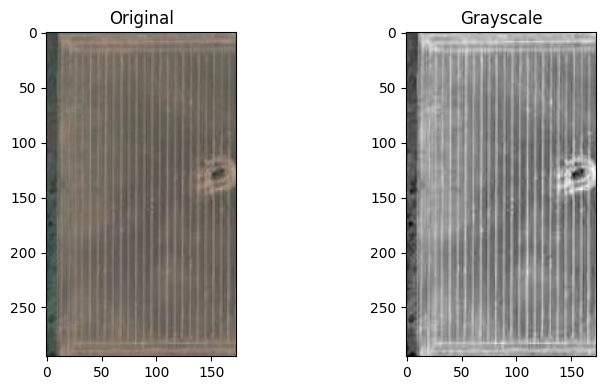

In [28]:
import matplotlib.pyplot as plt
import requests
import io
from skimage.io import imread
from skimage.color import rgb2gray

# Convert the GitHub URL to the raw file URL
url = "https://raw.githubusercontent.com/Jef-H/super_classy_fields/develop/crop_field_images/Screenshot%202025-01-17%20181339.png"

# Download the image
response = requests.get(url)
image = imread(io.BytesIO(response.content))

# Remove the alpha channel if present (RGBA → RGB)
image_rgb = image[..., :3]

# Convert to grayscale
grayscale = rgb2gray(image_rgb)

# Plot the images
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
ax = axes.ravel()

ax[0].imshow(image)
ax[0].set_title("Original")
ax[1].imshow(grayscale, cmap=plt.cm.gray)
ax[1].set_title("Grayscale")

fig.tight_layout()
plt.show()


# 2 Fill In Defects with inpainting (Filtering and restoration)



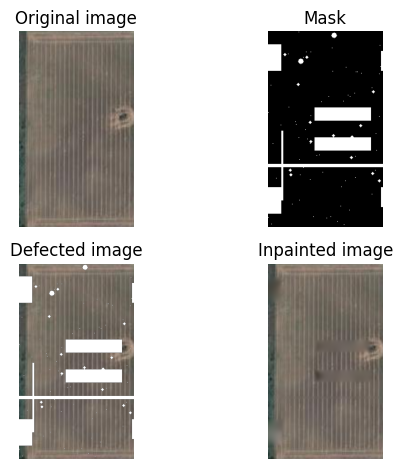

In [29]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data
from skimage.morphology import disk, binary_dilation
from skimage.restoration import inpaint

image_orig = image

# Create mask with six block defect regions
mask = np.zeros(image_orig.shape[:-1], dtype=bool)
mask[20:60, 0:20] = 1
mask[160:180, 70:155] = 1
mask[30:60, 170:195] = 1
mask[-60:-30, 170:195] = 1
mask[-180:-160, 70:155] = 1
mask[-60:-20, 0:20] = 1

# Add a few long, narrow defects
mask[200:205, -200:] = 1
mask[150:255, 20:23] = 1
mask[365:368, 60:130] = 1

# Add randomly positioned small point-like defects
rstate = np.random.default_rng(0)
for radius in [0, 2, 4]:
    # larger defects are less common
    thresh = 3 + 0.25 * radius  # make larger defects less common
    tmp_mask = rstate.standard_normal(image_orig.shape[:-1]) > thresh
    if radius > 0:
        tmp_mask = binary_dilation(tmp_mask, disk(radius, dtype=bool))
    mask[tmp_mask] = 1

# Apply defect mask to the image over the same region in each color channel
image_defect = image_orig * ~mask[..., np.newaxis]

image_result = inpaint.inpaint_biharmonic(image_defect, mask, channel_axis=-1)

fig, axes = plt.subplots(ncols=2, nrows=2)
ax = axes.ravel()

ax[0].set_title('Original image')
ax[0].imshow(image_orig)

ax[1].set_title('Mask')
ax[1].imshow(mask, cmap=plt.cm.gray)

ax[2].set_title('Defected image')
ax[2].imshow(image_defect)

ax[3].set_title('Inpainted image')
ax[3].imshow(image_result)

for a in ax:
    a.axis('off')

fig.tight_layout()
plt.show()

could be interesting to try and remove cloud cover or something like that.

# 3 Wavelet denoising (Filtering and restoration)

In [30]:
pip install Pywavelets


Estimated Gaussian noise standard deviation = 0.11961176631305108


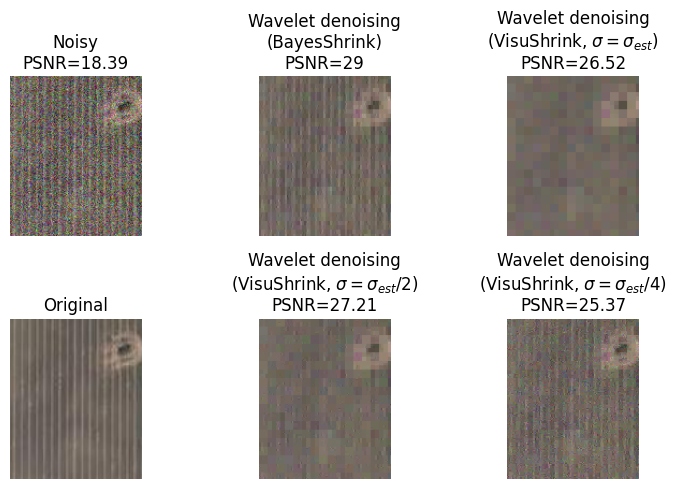

In [31]:
import matplotlib.pyplot as plt

from skimage.restoration import denoise_wavelet, estimate_sigma
from skimage import data, img_as_float
from skimage.util import random_noise
from skimage.metrics import peak_signal_noise_ratio

if image.shape[-1] == 4:  # Check if the image has an alpha channel
    image = image[..., :3]  # Keep only the first three channels (RGB)

original = img_as_float(image[100:250, 50:300])

sigma = 0.12
noisy = random_noise(original, var=sigma**2)

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(8, 5), sharex=True, sharey=True)

plt.gray()

# Estimate the average noise standard deviation across color channels.
sigma_est = estimate_sigma(noisy, channel_axis=-1, average_sigmas=True)
# Due to clipping in random_noise, the estimate will be a bit smaller than the
# specified sigma.
print(f'Estimated Gaussian noise standard deviation = {sigma_est}')

im_bayes = denoise_wavelet(
    noisy,
    channel_axis=-1,
    convert2ycbcr=True,
    method='BayesShrink',
    mode='soft',
    rescale_sigma=True,
)
im_visushrink = denoise_wavelet(
    noisy,
    channel_axis=-1,
    convert2ycbcr=True,
    method='VisuShrink',
    mode='soft',
    sigma=sigma_est,
    rescale_sigma=True,
)

# VisuShrink is designed to eliminate noise with high probability, but this
# results in a visually over-smooth appearance.  Repeat, specifying a reduction
# in the threshold by factors of 2 and 4.
im_visushrink2 = denoise_wavelet(
    noisy,
    channel_axis=-1,
    convert2ycbcr=True,
    method='VisuShrink',
    mode='soft',
    sigma=sigma_est / 2,
    rescale_sigma=True,
)
im_visushrink4 = denoise_wavelet(
    noisy,
    channel_axis=-1,
    convert2ycbcr=True,
    method='VisuShrink',
    mode='soft',
    sigma=sigma_est / 4,
    rescale_sigma=True,
)

# Compute PSNR as an indication of image quality
psnr_noisy = peak_signal_noise_ratio(original, noisy)
psnr_bayes = peak_signal_noise_ratio(original, im_bayes)
psnr_visushrink = peak_signal_noise_ratio(original, im_visushrink)
psnr_visushrink2 = peak_signal_noise_ratio(original, im_visushrink2)
psnr_visushrink4 = peak_signal_noise_ratio(original, im_visushrink4)

ax[0, 0].imshow(noisy)
ax[0, 0].axis('off')
ax[0, 0].set_title(f'Noisy\nPSNR={psnr_noisy:0.4g}')
ax[0, 1].imshow(im_bayes)
ax[0, 1].axis('off')
ax[0, 1].set_title(f'Wavelet denoising\n(BayesShrink)\nPSNR={psnr_bayes:0.4g}')
ax[0, 2].imshow(im_visushrink)
ax[0, 2].axis('off')
ax[0, 2].set_title(
    'Wavelet denoising\n(VisuShrink, $\\sigma=\\sigma_{est}$)\n'
    f'PSNR={psnr_visushrink:0.4g}'
)
ax[1, 0].imshow(original)
ax[1, 0].axis('off')
ax[1, 0].set_title('Original')
ax[1, 1].imshow(im_visushrink2)
ax[1, 1].axis('off')
ax[1, 1].set_title(
    'Wavelet denoising\n(VisuShrink, $\\sigma=\\sigma_{est}/2$)\n'
    f'PSNR={psnr_visushrink2:0.4g}'
)
ax[1, 2].imshow(im_visushrink4)
ax[1, 2].axis('off')
ax[1, 2].set_title(
    'Wavelet denoising\n(VisuShrink, $\\sigma=\\sigma_{est}/4$)\n'
    f'PSNR={psnr_visushrink4:0.4g}'
)
fig.tight_layout()

plt.show()

# 4 Dense DAISY feature Description ( Detection of Features and objects)


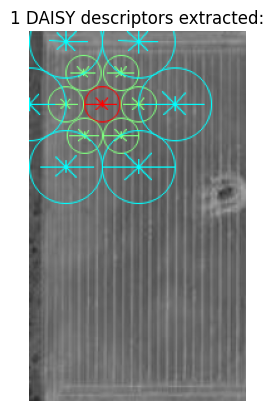

In [32]:
from skimage.feature import daisy
from skimage import data
import matplotlib.pyplot as plt

img = grayscale
descs, descs_img = daisy(
    img, step=180, radius=58, rings=2, histograms=6, orientations=8, visualize=True
)

fig, ax = plt.subplots()
ax.axis("off")
ax.imshow(descs_img)
descs_num = descs.shape[0] * descs.shape[1]
ax.set_title(f"{descs_num} DAISY descriptors extracted:")
plt.show()

# 5 Region adjacency graph (RAG) Thresholding


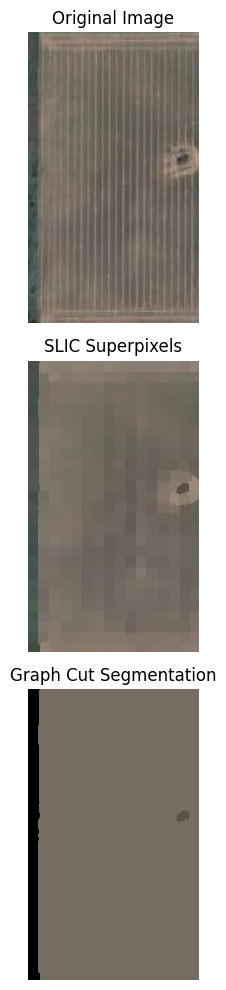

In [33]:
from skimage import io, segmentation, color
from skimage import graph
from matplotlib import pyplot as plt

# Load your image
img = image

# Apply SLIC segmentation
labels1 = segmentation.slic(img, compactness=30, n_segments=400, start_label=1)
out1 = color.label2rgb(labels1, img, kind='avg', bg_label=0)

# Apply Graph Cut segmentation
g = graph.rag_mean_color(img, labels1)
labels2 = graph.cut_threshold(labels1, g, 29)
out2 = color.label2rgb(labels2, img, kind='avg', bg_label=0)

# Create a figure with 3 subplots (Original, SLIC, Graph Cut)
fig, ax = plt.subplots(nrows=3, sharex=True, sharey=True, figsize=(6, 10))

# Show images
ax[0].imshow(img)       # Original Image
ax[1].imshow(out1)      # SLIC Superpixels
ax[2].imshow(out2)      # Graph Cut Segmentation

# Titles for each image
ax[0].set_title("Original Image")
ax[1].set_title("SLIC Superpixels")
ax[2].set_title("Graph Cut Segmentation")

# Remove axis labels
for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()


### Reflection.

There are a lot of built in features in sci-kit. I'm really interested in Object detection and de-noising of images so it was fun to play with the different features.